### Assignment 3: NLP Solutions for Real-World Problems

Group A - Intelligent Customer Service Systems

#### COMP8460
Khaliun Munkh-Ochir | 48715409

Ny Fenohery Jeannot | 48996637

Aashish Tomar | 48396214

# Import libraries

In [ ]:
!pip install -q wordcloud textblob vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.5 MB/s eta 0:00:00


In [ ]:
import nltk
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments
)
from datasets import Dataset
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
from transformers import set_seed
set_seed(42)
np.random.seed(42)

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# Load the dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("adisongoh/it-service-ticket-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'it-service-ticket-classification-dataset' dataset.
Path to dataset files: /kaggle/input/it-service-ticket-classification-dataset


In [ ]:
data = pd.read_csv('/kaggle/input/it-service-ticket-classification-dataset/all_tickets_processed_improved_v3.csv')

print(f"Dataset Shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print("\nFirst few rows:")
print(data.head())

Dataset Shape: (47837, 2)
Columns: ['Document', 'Topic_group']

First few rows:
                                            Document    Topic_group
0  connection with icon icon dear please setup ic...       Hardware
1  work experience user work experience user hi w...         Access
2  requesting for meeting requesting meeting hi p...       Hardware
3  reset passwords for external accounts re expir...         Access
4  mail verification warning hi has got attached ...  Miscellaneous


In [ ]:
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB
None


In [ ]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Document       0
Topic_group    0
dtype: int64


In [ ]:
print("\nTarget Variable Distribution:")
if 'Ticket Type' in data.columns:
    target_col = 'Ticket Type'
elif 'Category' in data.columns:
    target_col = 'Category'
elif 'Type' in data.columns:
    target_col = 'Type'
else:
    # Find the most likely target column
    for col in data.columns:
        if data[col].dtype == 'object' and data[col].nunique() < 10:
            target_col = col
            break

print(f"Target Column: {target_col}")
print(data[target_col].value_counts())
print(f"Number of classes: {data[target_col].nunique()}")


Target Variable Distribution:
Target Column: Topic_group
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64
Number of classes: 8


In [ ]:
# as there are a lot of rows in this data, we will be using only the first 1000
df = data.head(1000)
df

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous
...,...,...
995,change monitors change monitors hello please l...,Hardware
996,new starter starter form hi please help comple...,HR Support
997,password change contacted via phone requested,Access
998,monthly restart of the controller restart cont...,Hardware


# Basic techniques

### Preprocessing: Tokenization and Normalization

In [ ]:
# converting column from object to string
df['Document'] = df['Document'].astype(str)

# word tokenization, we will be focusing on word tokenization as it is appropriate for this task
df['word_tokens'] = df['Document'].apply(word_tokenize)

# removing stop words and lemmatizing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def cleaning(words):
    # applying lowercase
    words = [token.lower() for token in words]
    # applying punctutation removal
    words = [token for token in words if token.isalpha()]
    # applying stopword removal
    words = [token for token in words if token not in stop_words]
    # lemmatizing
    words = [lemmatizer.lemmatize(token) for token in words]

    return words

df['word_tokens'] = df['word_tokens'].apply(cleaning)

# joining the text for vectorizing later
df['joined_text'] = df['word_tokens'].apply(lambda tokens: ' '.join(tokens))
df['joined_text'].head()

,joined_text
0,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...
2,requesting meeting requesting meeting hi pleas...
3,reset password external account expire day hi ...
4,mail verification warning hi got attached plea...


### POS tagging for understanding query structure

In [ ]:
nlp = spacy.load("en_core_web_sm")

texts = df['joined_text'].astype(str).tolist()

pos_results = []
for doc in nlp.pipe(texts, batch_size=200, n_process=2):
    pos_results.append([(t.text, t.pos_) for t in doc])

df['pos_tags'] = pos_results

In [ ]:
# short sample of the output
for pos in pos_results[:1]:
  print(pos)

[('connection', 'NOUN'), ('icon', 'NOUN'), ('icon', 'NOUN'), ('dear', 'NOUN'), ('please', 'INTJ'), ('setup', 'VERB'), ('icon', 'NOUN'), ('per', 'ADP'), ('icon', 'NOUN'), ('engineer', 'NOUN'), ('please', 'INTJ'), ('let', 'VERB'), ('detail', 'NOUN'), ('needed', 'VERB'), ('thanks', 'NOUN'), ('lead', 'VERB')]


### NER for customer/product extraction

In [ ]:
def extract_entities_spacy(sentence):
    doc = nlp(sentence)

    entities = [(ent.text, ent.label_, ent.start_char, ent.end_char) for ent in doc.ents]
    return entities, doc

all_entities = []

for i, sentence in enumerate(df['joined_text'][:500], 1):
    print(f"\nSentence {i}: {sentence}")
    entities, doc = extract_entities_spacy(sentence)
    all_entities.extend(entities)

    if entities:
        print("Entities found:")
        for text, label, start, end in entities:
            print(f"  {text:<20} -> {label:<10} (chars {start}-{end})")
    else:
        print("  No entities found.")


Sentence 1: connection icon icon dear please setup icon per icon engineer please let detail needed thanks lead
  No entities found.

Sentence 2: work experience user work experience user hi work experience student coming next name much appreciate duration thank
  No entities found.

Sentence 3: requesting meeting requesting meeting hi please help follow equipment cable pc cord plug
Entities found:
  requesting meeting   -> PERSON     (chars 0-18)

Sentence 4: reset password external account expire day hi ask help update password colleague thank pm expire day importance high hi received expiration please kindly help prolongation best regard pm expire day importance high dear expire day order change please follow step prerequisite disable device credential close active connected cable machine note also follow step detailed press ctrl alt delete pop change item enter format enter enter newly chosen enter submit displaying changed o machine browse enter format enter gear icon top tight br

### Combining NER and POS

We will be inputting the extracted tags and entities into tasks further in the pipeline.

We will be extracting meaningful tags such VERBS and NOUNS, as they carry the most weight in this scenario.

As for entities, the output above shows that DATE was the most useful entitity in the data. There were issues with mislabelling for PERSON and ORG, so we have decided not to include them.

In [ ]:
final_df = []

for sentence in df['joined_text']:
  doc = nlp(sentence)
  pos_tags = [token.text for token in doc if token.pos_ in ("NOUN", "VERB")]
  entities = [ent.text for ent in doc.ents if ent.label_ in ("CARDINAL", "DATE")]
  final = " ".join(pos_tags + entities)

  final_df.append(final)

df['final_text'] = final_df
df[:3]

,Document,Topic_group,word_tokens,joined_text,pos_tags,final_text
0,connection with icon icon dear please setup ic...,Hardware,"[connection, icon, icon, dear, please, setup, ...",connection icon icon dear please setup icon pe...,"[(connection, NOUN), (icon, NOUN), (icon, NOUN...",connection icon icon dear setup icon icon engi...
1,work experience user work experience user hi w...,Access,"[work, experience, user, work, experience, use...",work experience user work experience user hi w...,"[(work, NOUN), (experience, NOUN), (user, NOUN...",work experience user work experience user work...
2,requesting for meeting requesting meeting hi p...,Hardware,"[requesting, meeting, requesting, meeting, hi,...",requesting meeting requesting meeting hi pleas...,"[(requesting, VERB), (meeting, NOUN), (request...",requesting meeting requesting meeting help fol...


### TF-IDF for knowledge base matching

In [ ]:
# initializing the vectorizer
t_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features = 3000, stop_words = 'english')

t_matrix = t_vectorizer.fit_transform(texts)
t_features = t_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(data=t_matrix.todense(), columns=t_features)
tfidf_df

,absence,absence allowance,absence leave,absence record,accept,accept decline,accept liability,accepted,accepted job,accepts,...,write write,writing,wrong,wrong record,wrote,year,yellow,yesterday,zone,zone computer
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
total_elements = t_matrix.shape[0] * t_matrix.shape[1]
non_zero_elements = t_matrix.nnz
sparsity = (1 - non_zero_elements / total_elements) * 100

print("TF-IDF Analysis:")
print("-" * 20)
print(f"TF-IDF Matrix shape: {t_matrix.shape}")
print(f"Vocabulary size: {len(t_features)}")
print(f"Sparsity: {sparsity:.1f}%")

TF-IDF Analysis:
--------------------
TF-IDF Matrix shape: (1000, 3000)
Vocabulary size: 3000
Sparsity: 99.0%


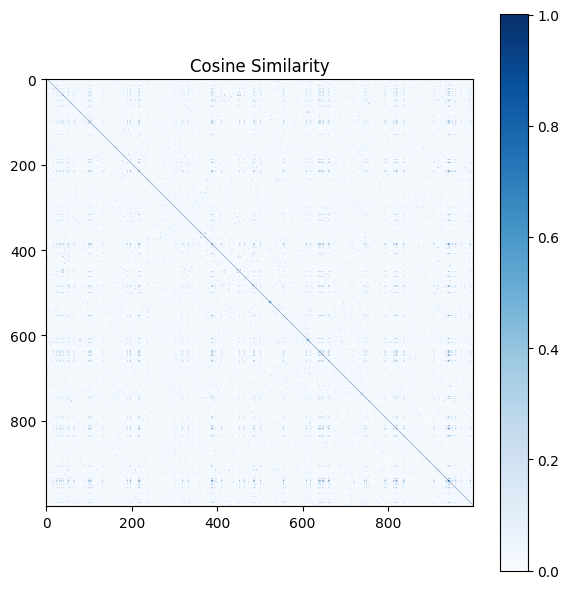

In [ ]:
tfidf = cosine_similarity(t_matrix)

plt.figure(figsize = (6, 6))
plt.imshow(tfidf, cmap='Blues')
plt.title('Cosine Similarity')
plt.colorbar()

plt.tight_layout()
plt.show()

As seen with the sparsity and graph, there is not much similarity between the texts in the document.

### Text Classification with ML Model

Train test split. Naive Bayes model initialization.

In [ ]:
# splitting
X = df['final_text']
y = df['Topic_group']

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# vectorize
X_train_tfidf = t_vectorizer.fit_transform(X_train)
X_test_tfidf = t_vectorizer.transform(X_test)

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred = nb_model.predict(X_test_tfidf)

Naive Bayes evaluation and visualization.

In [ ]:
print(f"Naive Bayes Classification Results:")

print(classification_report(y_test, y_pred,
                          target_names=list(y_train.unique())))

Naive Bayes Classification Results:
                       precision    recall  f1-score   support

             Hardware       0.70      0.59      0.64        27
        Miscellaneous       0.00      0.00      0.00         3
           HR Support       0.68      0.88      0.77        50
              Storage       0.52      0.66      0.58        38
             Purchase       0.00      0.00      0.00         9
     Internal Project       0.62      0.67      0.64        36
               Access       0.95      0.86      0.90        21
Administrative rights       1.00      0.38      0.55        16

             accuracy                           0.67       200
            macro avg       0.56      0.50      0.51       200
         weighted avg       0.65      0.67      0.64       200



<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

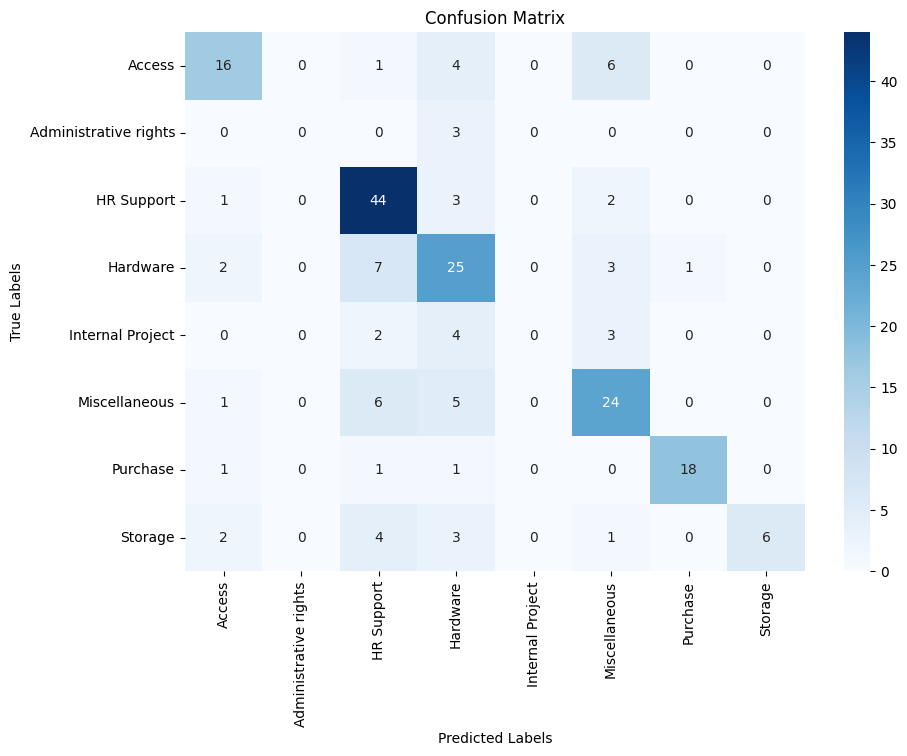

In [ ]:
cm = confusion_matrix(y_test, y_pred)

labels = sorted(y_test.unique())

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt

In [ ]:
# Initializing LogisticRegression
lr_model = LogisticRegression(random_state=42, max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_train_pred_lr = lr_model.predict(X_train_tfidf)
y_pred_lr = lr_model.predict(X_test_tfidf)

# evaluating the model
print(f"Logistic Regression Classification Results:")

print(classification_report(y_test, y_pred_lr,
                          target_names=list(y_train.unique())))

Logistic Regression Classification Results:
                       precision    recall  f1-score   support

             Hardware       0.62      0.48      0.54        27
        Miscellaneous       0.00      0.00      0.00         3
           HR Support       0.72      0.86      0.78        50
              Storage       0.47      0.76      0.58        38
             Purchase       1.00      0.22      0.36         9
     Internal Project       0.70      0.58      0.64        36
               Access       1.00      0.81      0.89        21
Administrative rights       1.00      0.50      0.67        16

             accuracy                           0.67       200
            macro avg       0.69      0.53      0.56       200
         weighted avg       0.71      0.67      0.66       200



### Sentiment Analysis

We've used VADER and TextBlob for sentiment analysis.

In [ ]:
# inspect VADER compound scores for each ticket

# initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

# create a new column with full VADER sentiment dictionary
df['vader_scores'] = df['final_text'].astype(str).apply(lambda x: analyzer.polarity_scores(x))

# extract the compound score only
df['compound'] = df['vader_scores'].apply(lambda x: x['compound'])

# display the first 20 samples with their scores
print(df[['final_text', 'compound']].head(20))

# see the full score breakdown (pos/neu/neg)
print("\nDetailed VADER scores example:")
for i in range(5):
    text = df['final_text'].iloc[i]
    scores = analyzer.polarity_scores(text)
    print(f"\nText {i+1}: {text}")
    print(f"Scores: {scores}")


                                           final_text  compound
0   connection icon icon dear setup icon icon engi...    0.6705
1   work experience user work experience user work...    0.6369
2   requesting meeting requesting meeting help fol...    0.4019
3   reset password account expire day ask help upd...    0.9153
4   mail verification warning attached address reg...   -0.5859
5   mail look blacklisted receiving mail sample at...    0.4404
6   server tunneling prod tunneling host host card...    0.6486
7   access request module report report cost thank...    0.3612
8   reset password client password dear password t...    0.6249
9   report missing time action report way help clo...    0.8126
10  laptop connected request rebuild rebuild provi...    0.0000
11  device recovery report printer unit set device...    0.2960
12                                  starter fill date    0.0000
13  studio license studio license developer studio...    0.3612
14  system movement left device kind dev

                                          final_text vader_sentiment  \
0  connection icon icon dear setup icon icon engi...         Neutral   
1  work experience user work experience user work...         Neutral   
2  requesting meeting requesting meeting help fol...         Neutral   
3  reset password account expire day ask help upd...        Positive   
4  mail verification warning attached address reg...         Neutral   
5  mail look blacklisted receiving mail sample at...         Neutral   
6  server tunneling prod tunneling host host card...         Neutral   
7  access request module report report cost thank...         Neutral   
8  reset password client password dear password t...         Neutral   
9  report missing time action report way help clo...        Positive   

  textblob_sentiment  
0           Positive  
1            Neutral  
2            Neutral  
3            Neutral  
4            Neutral  
5           Positive  
6            Neutral  
7            Neutral  


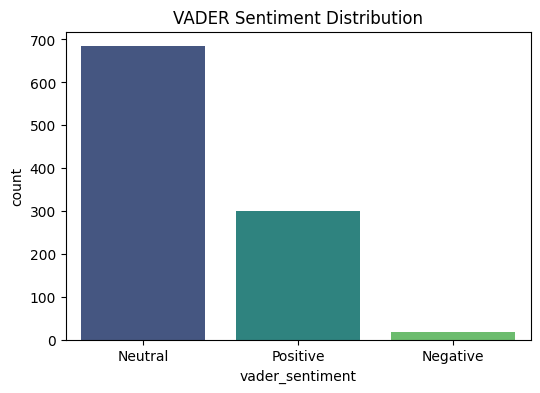

In [ ]:
# initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

# get sentiment scores
def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound > 0.675:
        return "Positive"
    elif compound < -0.675:
        return "Negative"
    else:
        return "Neutral"

df['vader_sentiment'] = df['final_text'].astype(str).apply(get_vader_sentiment)

# textBlob polarity as a comparison
def get_textblob_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['textblob_sentiment'] = df['final_text'].astype(str).apply(get_textblob_sentiment)

# show results
print(df[['final_text', 'vader_sentiment', 'textblob_sentiment']].head(10))

# compare distributions
plt.figure(figsize=(6,4))
sns.countplot(x=df['vader_sentiment'], palette='viridis')
plt.title("VADER Sentiment Distribution")
plt.show()

In [ ]:
samples = [
    "I'm having an issue with my order",
    "Thanks for resolving my problem",
    "Everything works great!",
    "Can't login to my account",
    "This product sucks and it will not work"
]

for s in samples:
    print("-------------------------------")
    print(s, "->", get_vader_sentiment(s))
    print(s, "->", get_textblob_sentiment(s))

-------------------------------
I'm having an issue with my order -> Neutral
I'm having an issue with my order -> Neutral
-------------------------------
Thanks for resolving my problem -> Neutral
Thanks for resolving my problem -> Positive
-------------------------------
Everything works great! -> Neutral
Everything works great! -> Positive
-------------------------------
Can't login to my account -> Neutral
Can't login to my account -> Neutral
-------------------------------
This product sucks and it will not work -> Neutral
This product sucks and it will not work -> Negative


# Advanced techniques

### LLM (with foundations models) for response generation

In [ ]:
# response generation with Qwen

# model selection
model_name = "Qwen/Qwen3-0.6B"   # change to "Qwen/Qwen3-4B" if you have GPU memory

# load tokenizer and model
qwen_tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
qwen_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True
)

def generate_with_qwen(prompt, max_length=300, temperature=0.7, do_sample=True):
    messages = [{"role": "user", "content": prompt}]
    text = qwen_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False   # avoid <think> output
    )
    model_inputs = qwen_tokenizer([text], return_tensors="pt")
    if torch.cuda.is_available():
        model_inputs = model_inputs.to(qwen_model.device)

    with torch.no_grad():
        output = qwen_model.generate(
            **model_inputs,
            max_new_tokens=max_length,
            temperature=temperature,
            top_p=0.9,
            do_sample=do_sample,
            pad_token_id=qwen_tokenizer.eos_token_id
        )

    result = qwen_tokenizer.decode(
        output[0][len(model_inputs.input_ids[0]):],
        skip_special_tokens=True
    ).strip()

    # remove any thinking blocks safely
    import re
    result = re.sub(r"<think>.*?</think>", "", result, flags=re.DOTALL).strip()

    if not result:
        result = "(No reply generated – try rerun.)"
    return result


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

### LLM prompt engineering techniques (including chain-of-thought prompting)

In [ ]:
# Few-shot + instruction-based prompt
def create_reply_prompt(review, sentiment, policy):
    return f"""You are a polite customer-service assistant.

Your job:
1. Read the customer review.
2. Consider the detected sentiment: {sentiment}.
3. Follow this policy guideline: {policy}
4. Write one short, polite company reply (2 sentences max).

Example 1:
Review: "The delivery was super fast and packaging was neat!"
Sentiment: positive
Policy: If feedback is positive, thank the customer and invite them to shop again.
Reply: "Thanks for your kind words! We’re glad your order arrived quickly and we hope to serve you again soon."

Example 2:
Review: "My order arrived late and nobody replied to my emails."
Sentiment: negative
Policy: If delivery issues occur, apologise and offer tracking support or replacement.
Reply: "We’re really sorry for the delay and lack of communication. Please share your order details so we can resolve this quickly."

Now write a new reply.

Review: "{review}"
Sentiment: {sentiment}
Policy: {policy}
Reply:
"""


### RAG for company knowledge retrieval

In [ ]:
# Policy retrieval (RAG)

# define small policy library (3–5 snippets)
policies = [
    "Be polite and concise. If negative, apologise and offer help or refund.",
    "If delivery issues occur, apologise and offer tracking support or replacement.",
    "If product quality problems appear, apologise and suggest replacement or refund.",
    "If feedback is positive, thank the customer and invite them to shop again.",
    "If the comment is neutral, thank them and note their feedback for improvement.",
    "Always maintain a helpful and respectful tone regardless of sentiment."
]

# build TF-IDF vectors for the policy set
policy_vectorizer = TfidfVectorizer()
P = policy_vectorizer.fit_transform(policies)

# define retrieval function
def retrieve_policy_snippet(review_text: str, top_k: int = 1) -> str:
    """Return the most relevant company policy snippet for a given review."""
    q = policy_vectorizer.transform([review_text])
    sims = cosine_similarity(q, P).ravel()
    idx = sims.argsort()[::-1][:top_k]
    return " ".join([policies[i] for i in idx])


In [ ]:
# quick tests
test_reviews = [
    "My package arrived late and the product was broken.",
    "Great service and fast delivery, very happy!",
    "The app works fine but the layout could be better."
]

for r in test_reviews:
    snippet = retrieve_policy_snippet(r)
    print("-"*80)
    print(f"Review:  {r}")
    print(f"Retrieved policy: {snippet}")

--------------------------------------------------------------------------------
Review:  My package arrived late and the product was broken.
Retrieved policy: If product quality problems appear, apologise and suggest replacement or refund.
--------------------------------------------------------------------------------
Review:  Great service and fast delivery, very happy!
Retrieved policy: If delivery issues occur, apologise and offer tracking support or replacement.
--------------------------------------------------------------------------------
Review:  The app works fine but the layout could be better.
Retrieved policy: If the comment is neutral, thank them and note their feedback for improvement.


In [ ]:
# response generation

def generate_reply_qwen(review, sentiment, use_retrieval=True):
    """Full reply generator using Qwen model and retrieved policy."""
    policy = retrieve_policy_snippet(review) if use_retrieval else ""
    prompt = create_reply_prompt(review, sentiment, policy)
    reply = generate_with_qwen(prompt, max_length=300, temperature=0.7, do_sample=True)
    return reply.strip()

### Demonstration

In [ ]:
# Demonstration

def full_pipeline(review_text):
    """Run the complete feedback workflow."""

    # classify sentiment
    sentiment = get_vader_sentiment(review_text)

    # retrieve relevant policy
    policy = retrieve_policy_snippet(review_text)

    # generate reply with Qwen
    reply = generate_reply_qwen(review_text, sentiment, use_retrieval=True)

    return {
        "review": review_text,
        "sentiment": sentiment,
        "policy": policy,
        "reply": reply
    }

# pick n random rows
n = 10
samples = df['final_text'].sample(n, random_state=42)

results = [full_pipeline(r) for r in samples]

# display results
for res in results:
    print("-"*100)
    print(f"Review:    {res['review']}")
    print(f"Sentiment: {res['sentiment']}")
    print(f"Policy:    {res['policy']}")
    print(f"Reply:     {res['reply']}")


----------------------------------------------------------------------------------------------------
Review:    period adjustment rise ticket rise ticket assign summary period adjustment requester kind regard engineer december december
Sentiment: Neutral
Policy:    Always maintain a helpful and respectful tone regardless of sentiment.
Reply:     We're grateful for the information. The period adjustment request was received, and we appreciate your support. Please feel free to reach out if you need further assistance.
----------------------------------------------------------------------------------------------------
Review:    access floor floor member starting today ask floor floor floor thank regard self today
Sentiment: Neutral
Policy:    If the comment is neutral, thank them and note their feedback for improvement.
Reply:     Thanks for the note! We appreciate your feedback and hope to serve you again. Let me know if there's anything else we can help with.
--------------------------

### Dialogue state tracking

In [ ]:
class DialogueStateTracker:
    def __init__(self):
        self.state = {
            "intent": None,      # will come from Topic_group
            "entities": {},      # extracted (e.g., order id)
            "stage": "start"     # start → ask_info → resolving → done
        }

    def set_intent_from_dataset(self, topic_group_label):
        """Assigns the ticket's Topic_group as the intent."""
        self.state["intent"] = topic_group_label

    def extract_entities(self, text):
        """Toy example — you can extend using spaCy NER."""
        text_low = text.lower()

        # simulate order detection
        if "order" in text_low:
            self.state["entities"]["order_id"] = "UNKNOWN_ORDER"

        # simulate account detection
        if "account" in text_low:
            self.state["entities"]["account"] = "mentioned"

    def next_stage(self):
        """Move dialogue stage to the next logical step."""
        if self.state["stage"] == "start":
            self.state["stage"] = "ask_info"
        elif self.state["stage"] == "ask_info":
            self.state["stage"] = "resolving"
        else:
            self.state["stage"] = "done"

    def process_turn(self, user_text, topic_group):
        """Main DST update function used in your pipeline."""
        self.set_intent_from_dataset(topic_group)   # intent comes from dataset
        self.extract_entities(user_text)            # extract basic entities
        self.next_stage()                           # update stage
        return self.state


In [ ]:
tracker = DialogueStateTracker()

sample_rows = df.sample(5, random_state=42)

for idx, row in sample_rows.iterrows():
    state = tracker.process_turn(
        user_text=row['final_text'],
        topic_group=row['Topic_group']
    )

    print("\n--- Ticket", idx, "---")
    print("Text:", row['final_text'])
    print("Topic_group:", row['Topic_group'])
    print("Updated DST State:", state)


--- Ticket 521 ---
Text: period adjustment rise ticket rise ticket assign summary period adjustment requester kind regard engineer december december
Topic_group: Miscellaneous
Updated DST State: {'intent': 'Miscellaneous', 'entities': {}, 'stage': 'ask_info'}

--- Ticket 737 ---
Text: access floor floor member starting today ask floor floor floor thank regard self today
Topic_group: HR Support
Updated DST State: {'intent': 'HR Support', 'entities': {}, 'stage': 'resolving'}

--- Ticket 740 ---
Text: reset password client client dear atom updated credential thank ask update atom thanks
Topic_group: Access
Updated DST State: {'intent': 'Access', 'entities': {}, 'stage': 'done'}

--- Ticket 660 ---
Text: catch catch let client thanks catch failed group permission issue rejected moderator accept sender restriction preventing information administrator generating returned client authenticated return path version bit verify i we aw bar sc ox msg tower originating version banner checked tower

### Automated escalation using LLM classification

In [ ]:
# rule-based escalation

def needs_escalation_rule_based(text):
    text_low = text.lower()

    escalation_keywords = [
        "angry", "upset", "furious", "complaint", "cancel my account",
        "refund", "fraud", "scam", "lawsuit", "not acceptable",
        "speak to a manager", "escalate", "supervisor", "threaten"
    ]

    for word in escalation_keywords:
        if word in text_low:
            return True

    # additional rule: very negative VADER
    if analyzer.polarity_scores(text)["compound"] < -0.675:
        return True

    return False

In [ ]:
def needs_escalation_llm(text):
    prompt = f"""
You are an assistant that decides whether a customer request should be escalated to a human agent.

A request should be escalated when:
- the customer is very angry or threatening,
- the customer asks to cancel the account,
- the issue involves payment, fraud, or security,
- the same problem happened many times,
- the model cannot solve the issue safely.

Respond with exactly one word: "yes" or "no".

Customer message:
"{text}"
"""

    reply = generate_with_qwen(
        prompt,
        max_length=50,
        temperature=0.01,
        do_sample=False
    )

    reply = reply.lower().strip()
    if "yes" in reply:
        return True
    return False

In [ ]:
# full pipeline with escalation

def full_pipeline_with_escalation(review_text):
    sentiment = get_vader_sentiment(review_text)
    policy = retrieve_policy_snippet(review_text)
    reply = generate_reply_qwen(review_text, sentiment)

    # escalation mechanisms
    esc_rule = needs_escalation_rule_based(review_text)
    esc_llm = needs_escalation_llm(review_text)

    # final escalation flag
    final_escalate = esc_rule or esc_llm

    return {
        "review": review_text,
        "sentiment": sentiment,
        "policy": policy,
        "reply": reply,
        "escalate_rule_based": esc_rule,
        "escalate_llm": esc_llm,
        "final_escalate": final_escalate
    }


In [ ]:
# Example

sample = "I am extremely angry! This is unacceptable and I want to file a complaint. Cancel my account."

result = full_pipeline_with_escalation(sample)

for k, v in result.items():
    print(k, ":", v)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


review : I am extremely angry! This is unacceptable and I want to file a complaint. Cancel my account.
sentiment : Negative
policy : If feedback is positive, thank the customer and invite them to shop again.
reply : We’re sorry for your complaint and will take action to resolve it. If you have any questions, feel free to reach out.
escalate_rule_based : True
escalate_llm : True
final_escalate : True
